### AI_multimodal_data_distribution

In [1]:
import import_ipynb
from AI_multimodal20210922 import *


importing Jupyter notebook from AI_multimodal20210922.ipynb
결측치 제거 전 전체 크기 :  1579
결측치 제거 후 전체 크기 :  1575
<class 'pandas.core.frame.DataFrame'>


importing Jupyter notebook from predicate_distribution.ipynb
labels_clip_13: ['catch', 'eat_drink', 'sit']
labels_clip_30: ['catch', 'eat_drink']


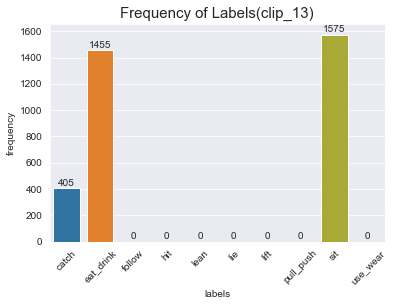

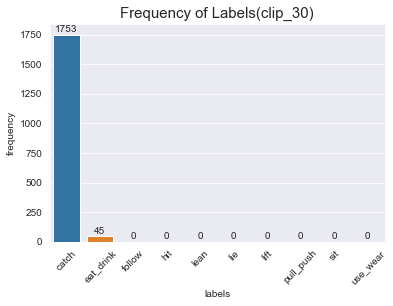

In [2]:
from predicate_distribution import * 

#### 개인 PC 경로에 맞게 path를 설정하세요

In [3]:
Path = "C:/Users/user/OneDrive/Desktop/연구실/2019-01-005.멀티모달영상_sample (1)/라벨데이터/"
File_name1 = "clip_13.json"
File_name2 = "clip_30.json"

In [4]:
with open(Path+File_name1,"r",encoding='UTF8') as clip13_json:
    clip_13 = json.load(clip13_json)

with open(Path+File_name2,"r",encoding='UTF8') as clip30_json:
    clip_30 =json.load(clip30_json)


### 1. 폴더 하나에 400개에 달하는 json파일과 클립이 있습니다. 
- 개선점 1 : 일일이 경로를 정해서 with를 쓰지 않고 일괄적으로 json을 불러올 수 있도록, Pathlist와 Path를 할당합니다.
- 경로 + clip의 번호 이렇게만 입력해주시면 됩니동.

#### 1-1) get_json_list() : 위의 기능을 실제로 진행합니다.
 - 경로와 clip의 번호를 넘기면, 그에 맞는 json파일을 일괄적으로 불러오고,
 - 전역 할당되어 있는 Pathlist와 cliplist에 들어갑니다.
 - cliplist에 이전에 쓰였던 clip_13,clip_30과 같은 raw data가 들어갈 것입니다. 
 - 그냥 복잡하시면 cliplist만 보시면 됩니다. cliplist 안에 모든 json파일이 들어갑니다.!
 
 - clip'1'.json은 cliplist[1]에 들어가 있습니다. 그리고 cliplist[0]에는 dummy라는 쓰레기가 있습니다.
 - 왜냐하면, 좀더 편하게 보시라고 인덱스가 1씩 밀리는 게 불편하실까봐 처리하였습니다.

In [135]:
Pathlist = []

cliplist=['dummy']
Path = "C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400"
#400개라.. 
#Path + clip번호 + File_name 이런 형식이 되어야 합니다. 
#C:\Users\user\OneDrive\Desktop\연구실\Multimodal\0001-0400\clip_1
#"C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_"

def get_json_list(Path,n_iter):
    curPath = Path+"/clip_"
    for i in range(1,n_iter+1):
        resPath= curPath+str(i)+"/clip_"+str(i)+".json"
        print(resPath)
        
        with open(resPath,"r",encoding='UTF8') as curclip:
            cliplist.append(json.load(curclip))
        
        
    
    
    

In [136]:
get_json_list(Path,20)

C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_1/clip_1.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_2/clip_2.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_3/clip_3.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_4/clip_4.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_5/clip_5.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_6/clip_6.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_7/clip_7.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_8/clip_8.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_9/clip_9.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_10/clip_10.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_11/clip_11.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_12/clip_12.json
C:/Users/user/OneDrive/Desktop/연구실/Multimodal/0001-0400/clip_13/clip_13.json
C:/Users/user/One

In [137]:
#cliplist[1]

#### 1-2) Data_column_list 객체란? : 
 - cliplist(json) -> Data_column_list(DataFrame)으로 변환하는 과정이 필요합니다.
 - get_data_column_list()함수를 통해서 cliplist에 있는 json파일을 dataFrame으로 만든 다음 
 - 그 모든 dataFrame을 전부 집어넣은 리스트입니다.

###  엥? 한 폴더 당 400개의 json을 DataFrame으로 바꾸면 너무 오래걸리지 않나요?
 - 그래서 cliplist의 범위를 정해줘서 샘플만을 놓고 DataFrame을 바꿔줄 수 있도록
 - 원하는 범위를 인자로 넘겨주도록 하겠습니다. 
 - 한 폴더 당 총 400개에 달하는 json파일인데 1<=N<=400의 범위 내에서 원하는 대로 DataFrame을 형성할 수 있습니다.
 
 
#### 1-3) get_dataframe() : 범위를 입력하면 전역 선언된 cliplist에서 일부를 따오고, 그만큼 DataFrame을 담은 리스트를 반환합니다.
 - 전역 선언을 하지 않고, 원하는 만큼만 따올 수 있도록 리스트를 반환하였습니다.

In [13]:
#cliplist는 이미 모든 json파일이 들어가 있음. 400개를 전체 모수로 가정하였을 때. 
def get_dataframe(n_iter):
    res_dataframe_list=[]
    
    #1부터 10까지 응엽
    for i in range(1,n_iter+1):
        cur_dataframe = get_data_column_list(cliplist[i])
        res_dataframe_list.append(cur_dataframe)
    
    return res_dataframe_list

In [14]:
#10개만 따로 보도록 하겠습니다.
import time 
a = time.time()
res_dataframe_list = get_dataframe(10)
b= time.time()

print(b-a)

37.62509322166443


- 잘 나오긴 하는데, 문제가 있습니다. 
- 'predicate'가 column으로 들어가있는 dataframe도 있고, 없는 frame도 있습니다.
- 심지어 column의 개수도 상황에 따라 다름을 확인할 수 있습니다.


In [15]:
for key, value in enumerate(res_dataframe_list):
    cur_dataframe = value
    cnt=0
    for i in cur_dataframe.columns:
        if i =='person_id' or i == 'emotion' or i == 'predicate' or i == 'xtl' or i == 'ybr' or i == 'ytl' or i == 'frame' or i =='xbr' or i == 'label' or i == 'position' or i == 'text':
            cnt+=1
    print(key,cnt)
    

0 11
1 11
2 11
3 10
4 10
5 11
6 11
7 11
8 11
9 10


In [16]:
# for key,value in enumerate(res_dataframe_list):
#     print(key,len(value.columns))

In [17]:
# for key,value in enumerate(res_dataframe_list):
#     print(key, value.columns)

#### get_predicate_labels : predicate(행동관계정보)의 라벨을 반환합니다.
- 그런데, 각 frame을 담은 dataframe마다 predicate라는 columns을 담지 않는 경우도 있어서,
- 이에 대한 분기를 해줘야 합니다.

In [18]:
# for key,value in enumerate(res_dataframe_list):
#     if 'predicate' in res_dataframe_list[key].columns:
#         print(key,value.columns)

0 Index(['person_id', 'emotion', 'predicate', 'xtl', 'ybr', 'ytl', 'frame',
       'xbr', 'label', 'position', 'text', '남성이 몇 명있나요?', '여자가 몇 명있나요?',
       '여자가 있나요?', '남성이 있나요?', '남자가 있나요?', '남자가 몇 명있나요?', '여성이 몇 명있나요?',
       '여성이 있나요?'],
      dtype='object')
1 Index(['label', 'xtl', 'ybr', 'ytl', 'frame', 'xbr', 'person_id', 'emotion',
       'predicate', 'position', 'text', '남성이 몇 명있나요?', '여자가 몇 명있나요?',
       '양초가 있나요?', '남성이 있나요?', '전화기가 있나요?', '여자가 있나요?', '전화기는 몇 개인가요?',
       '양초는 몇 개인가요?', '사람은 몇 명인가요?', '여성이 몇 명있나요?', '여성이 있나요?', '포크는 몇 개인가요?',
       '포크가 있나요?', '노트는 몇 개인가요?', '노트가 있나요?', '남자가 몇 명있나요?', '남자가 있나요?',
       '모니터는 몇 개인가요?', '모니터가 있나요?'],
      dtype='object')
2 Index(['person_id', 'emotion', 'frame', 'predicate', 'ytl', 'position', 'xtl',
       'text', 'xbr', 'label', 'ybr', '여자가 몇 명있나요?', '남자가 몇 명있나요?',
       '빗자루가 있나요?', '빗자루는 몇 개인가요?', '전화기가 있나요?', '여자가 있나요?', '전화기는 몇 개인가요?',
       '남자가 있나요?', '남성이 몇 명있나요?', '여성이 몇 명있나요?', '남성이 있나요?', '여성이 있나요?',
     

In [19]:
# def get_predicate_labels(inputlist):
#     labels=[]
#     #inputlist는 frame을 datafame으로 바꾼 것들을 모아놓은 응엽리스트를 말함
#     for i in range(len(inputlist)):
        
#         if 'predicate' in inputlist[i].columns:
#             #inputlist[i] 즉 i번째 frame dataframe에는 predicate라는 columns이 있다는 소리임
#                print(i)

In [20]:
# get_predicate_labels(res_dataframe_list)


#### Predicate columns 를 가지고 있는 frame Dataframe만 따로 저장을 해놓고 진행

- get_predicate_frame : predicate를 갖고 있는 전체 dataframe을 담은 list를 반환

In [21]:
def get_predicate_frame(n_iter):
    predicate_having_dataframe_list = ['dummy'] 
    total_dataframe_list = get_dataframe(n_iter)
    
    for i in range(1,len(total_dataframe_list)):
        if 'predicate' in total_dataframe_list[i].columns:
            
            predicate_having_dataframe_list.append(total_dataframe_list[i])
    return predicate_having_dataframe_list       

In [41]:
predicate_having_frame_list = get_predicate_frame(10)
predicate_having_frame_list[2]




,person_id,emotion,frame,predicate,ytl,position,xtl,text,xbr,label,...,전화기는 몇 개인가요?,남자가 있나요?,남성이 몇 명있나요?,여성이 몇 명있나요?,남성이 있나요?,여성이 있나요?,수저가 있나요?,수저는 몇 개인가요?,마이크는 몇 개인가요?,마이크가 있나요?
2,2,"{'image': {'valence': 0, 'arousal': 0}, 'text'...",128,{'4': 'sit'},195.60,"{'4': 'on', '1': 'ahead'}",881.00,"{'script_end': 129, 'strategy': 'QESD', 'scrip...",1319.14,person,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,128,NaN,411.10,NaN,512.29,NaN,893.80,chair,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"{'image': {'valence': 0, 'arousal': 0}}",128,{'3': 'sit'},184.48,"{'2': 'ahead', '3': 'on'}",574.23,NaN,950.60,person,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,128,NaN,436.30,NaN,830.56,NaN,1153.10,table,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,128,NaN,419.90,NaN,1041.65,NaN,1396.82,chair,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,1,NaN,366,{'3': 'sit'},183.40,"{'6': 'close', '2': 'ahead', '3': 'on'}",571.50,NaN,992.00,person,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,366,NaN,436.30,NaN,830.56,NaN,1153.10,table,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,366,NaN,439.50,"{'2': 'ahead', '1': 'close', '5': 'on'}",973.61,NaN,1046.44,phone,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,366,{'4': 'sit'},207.35,"{'6': 'close', '4': 'on', '1': 'ahead'}",881.00,NaN,1324.10,person,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2) 분포 확인 
 - 전역으로 predicate를 잡아 놓고, 10개의 데이터에 대해서만 분포를 구하는 작업을 시작하겠습니다. 

In [113]:
frequency_labels = {
        'catch':0,
        'eat_drink':0,
        'follow':1,
        'hit':0,
        'lean':0,
        'lie':0,
        'lift':0,
        'pull_push':0,
        'sit':0,
        'use_wear':0
    }


In [114]:
list(frequency_labels.values())[2]

1

In [115]:
# def dropna_in_predicate(n_iter):
#     predicate_having_dataframe_list = get_predicate_frame(n_iter)
#     predicate_having_dataframe_list = pd.array(predicate_having_dataframe_list['predicate'])
#     predicatelist=[]
#     for i in range(len(n_iter)):
#         predicatelist.append(predicate_having_dataframe_list[i]['predicate'].dropna())
#     return predicatelist

#### get_data_column_list를 개선하였습니다.
 - 전체 dataframe이 들어간 리스트에서, 
 - 원하는 column과, 원하는 크기를 입력하면 그에 걸맞는 Series객체를 리턴하는 함수

In [117]:
#cliplist는 이미 모든 json파일이 들어가 있음. 400개를 전체 모수로 가정하였을 때. 
def get_dataframe(n_iter):
    res_dataframe_list=[]
    
    #1부터 10까지 응엽
    for i in range(1,n_iter+1):
        cur_dataframe = get_data_column_list(cliplist[i])
        res_dataframe_list.append(cur_dataframe)
    
    return res_dataframe_list

In [129]:
def get_data_column_list_(column,n_iter):
    res_data_frame_list=[]
    
    for i in range(1,n_iter+1):
        #1. 클립리스트 -> 전체 dataframe으로 변환
        cur_dataframe1 = get_data_column_list(cliplist[i])
        #2. 그 가운데 입력받은 column에 대해서만 추출한 DataFrame
        if column not in cur_dataframe1.columns:
            pass
        else:
            cur_dataframe1 = cur_dataframe1[[column]]
            
            #결측치를 제거하고 싶다면 아래 코드를 실행시키면 됩니다.
            cur_dataframe1 = cur_dataframe1.dropna()
            res_data_frame_list.append(cur_dataframe1)
    return res_data_frame_list

In [133]:
#tmp  = get_data_column_list_('emotion',3)
#tmp[2]